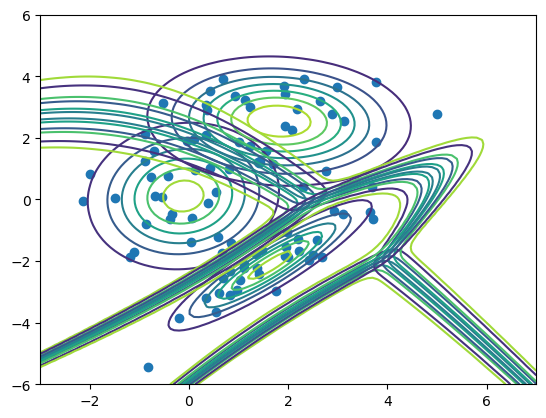

In [1]:
from matplotlib import pyplot as plt
from scipy.stats import multivariate_normal, norm
import numpy as np
import sympy as sp
import pandas as pd
from timeit import default_timer as timer 

data=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/data_plotcc.csv'))
t=data[:,0]; X=data[:,1:3]; X1=X[t==1]; X2=X[t==2]; X3=X[t==3]

# Fig 5-2 for likelihood
mu1=[np.mean(X1[:,0]),np.mean(X1[:,1])]; mu2=[np.mean(X2[:,0]),np.mean(X2[:,1])]; mu3=[np.mean(X3[:,0]),np.mean(X3[:,1])];
Sig1=(X1-mu1).T@(X1-mu1)/len(X1); Sig2=(X2-mu2).T@(X2-mu2)/len(X2); Sig3=(X3-mu3).T@(X3-mu3)/len(X3)
# print(mu1, Sig1)
x1=np.linspace(-3,7,101)
x2=np.linspace(-6,6,101)
X1, X2=np.meshgrid(x1, x2)
X1.shape
Z1=[[multivariate_normal.pdf([X1[i,j], X2[i,j]], mu1, Sig1) for j in range(len(X1[0]))] for i in range(len(X1))]
Z2=[[multivariate_normal.pdf([X1[i,j], X2[i,j]], mu2, Sig2) for j in range(len(X1[0]))] for i in range(len(X1))]
Z3=[[multivariate_normal.pdf([X1[i,j], X2[i,j]], mu3, Sig3) for j in range(len(X1[0]))] for i in range(len(X1))]
plt.contour(x1, x2, Z1)
plt.contour(x1, x2, Z2)
plt.contour(x1, x2, Z3)
plt.scatter(X[:,0],X[:,1])

# Fig 5-3 for predictive probability
prior=[1/3, 1/3, 1/3]
class1=np.array(Z1)*prior[0]/(np.array(Z1)*prior[0]+np.array(Z2)*prior[1]+np.array(Z3)*prior[2])
class2=np.array(Z2)*prior[1]/(np.array(Z1)*prior[0]+np.array(Z2)*prior[1]+np.array(Z3)*prior[2])
class3=np.array(Z3)*prior[2]/(np.array(Z1)*prior[0]+np.array(Z2)*prior[1]+np.array(Z3)*prior[2])
plt.contour(x1, x2, class1)
plt.contour(x1, x2, class2)
plt.contour(x1, x2, class3)


In [2]:
from scipy.stats import multivariate_normal
import numpy as np

priors = np.array([1/3, 1/3, 1/3])
x_new = np.array([2.0, 0.0])

like1_new = multivariate_normal.pdf(x_new, mean=mu1, cov=Sig1)
like2_new = multivariate_normal.pdf(x_new, mean=mu2, cov=Sig2)
like3_new = multivariate_normal.pdf(x_new, mean=mu3, cov=Sig3)

print("p(x_new|c=1) =", round(like1_new, 4))
print("p(x_new|c=2) =", round(like2_new, 4))
print("p(x_new|c=3) =", round(like3_new, 4))

evidence = like1_new*priors[0] + like2_new*priors[1] + like3_new*priors[2]

post1 = like1_new * priors[0] / evidence
post2 = like2_new * priors[1] / evidence
post3 = like3_new * priors[2] / evidence

print("p(c=1|x_new) =", round(post1, 4))
print("p(c=2|x_new) =", round(post2, 4))
print("p(c=3|x_new) =", round(post3, 4))


p(x_new|c=1) = 0.0132
p(x_new|c=2) = 0.0057
p(x_new|c=3) = 0.0001
p(c=1|x_new) = 0.6952
p(c=2|x_new) = 0.2975
p(c=3|x_new) = 0.0073


In [ ]:
sumlist = []
for i in range(10000):
    grp = np.random.choice([1,2,3], size = 3)
    sample = []
    for j in range(len(grp)):
        if grp[j] == 1:
            x = norm.rvs(1, 1)
            sample.append(x)
        if grp[j] == 2:
            y = norm.rvs(4, 1)
            sample.append(y)
        if grp[j] == 3:
            z = norm.rvs(7, 1)
            sample.append(z)
    sumlist.append(sample)

plt.hist(sumlist, bins = 60, density = True)
print(f'mean: {np.mean(sumlist)}')
print(f'std: {np.std(sumlist)}')
print(f'sqrt: {np.sqrt(1+1+1)}')

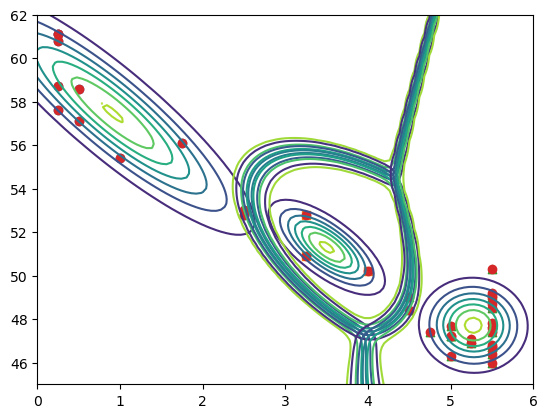

In [ ]:
data=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/data_switching.csv'))
t=data[:,0]; X=np.array(data[:,[2,3]]); 
plt.scatter(X[t==1][:,0], X[t==1][:,1],marker='o')
plt.scatter(X[t==2][:,0], X[t==2][:,1],marker='s')
plt.scatter(X[t==3][:,0], X[t==3][:,1],marker='^')
X1=X[t==1]; X2=X[t==2]; X3=X[t==3]

# Fig 5-2 for likelihood
mu1=[np.mean(X1[:,0]),np.mean(X1[:,1])]; mu2=[np.mean(X2[:,0]),np.mean(X2[:,1])]; mu3=[np.mean(X3[:,0]),np.mean(X3[:,1])];
Sig1=(X1-mu1).T@(X1-mu1)/len(X1); Sig2=(X2-mu2).T@(X2-mu2)/len(X2); Sig3=(X3-mu3).T@(X3-mu3)/len(X3)
x1=np.linspace(0,6,101)
x2=np.linspace(45,62,101)
X1, X2=np.meshgrid(x1, x2)
X1.shape
Z1=[[multivariate_normal.pdf([X1[i,j], X2[i,j]], mu1, Sig1) for j in range(len(X1[0]))] for i in range(len(X1))]
Z2=[[multivariate_normal.pdf([X1[i,j], X2[i,j]], mu2, Sig2) for j in range(len(X1[0]))] for i in range(len(X1))]
Z3=[[multivariate_normal.pdf([X1[i,j], X2[i,j]], mu3, Sig3) for j in range(len(X1[0]))] for i in range(len(X1))]
plt.contour(x1, x2, Z1)
plt.contour(x1, x2, Z2)
plt.contour(x1, x2, Z3)
plt.scatter(X[:,0],X[:,1])

# Fig 5-3 for predictive probability
prior=[1/3, 1/3, 1/3]
class1=np.array(Z1)*prior[0]/(np.array(Z1)*prior[0]+np.array(Z2)*prior[1]+np.array(Z3)*prior[2])
class2=np.array(Z2)*prior[1]/(np.array(Z1)*prior[0]+np.array(Z2)*prior[1]+np.array(Z3)*prior[2])
class3=np.array(Z3)*prior[2]/(np.array(Z1)*prior[0]+np.array(Z2)*prior[1]+np.array(Z3)*prior[2])
plt.contour(x1, x2, class1)
plt.contour(x1, x2, class2)
plt.contour(x1, x2, class3)

# test=np.array(pd.read_csv('/Users/liaoweihong/Desktop/Python/DAML/test_switching.csv'))
# test[0]
# plt.contour(x1, x2, class2, colors='k')
# plt.scatter(test[:,4],test[:,5])
# plt.scatter(X[t==2][:,0], X[t==2][:,1],marker='s')

In [ ]:
import csv
from selenium import webdriver
from selenium.webdriver.support.select import Select
from selenium.webdriver.chrome.service import Service # new
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By # new
from bs4 import BeautifulSoup as bs

stocknum = []

with open('stocknum.csv', newline = '') as csvfile:
    for line in csv.reader(csvfile):
        stocknum.append(line[0])

with open('20250418.csv', 'w', newline = '') as csvfile:
    service = Service(executable_path='C:/Temp/chromedriver.exe')
    options = webdriver.ChromeOptions()
    options.add_argument('--headless')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    browser = webdriver.Chrome()
    browser.get(r"https://www.tdcc.com.tw/portal/zh/smWeb/qryStock")

    writer = csv.writer(csvfile)
    writer.writerow(['資料日期', '證券代號', '序', '持股/單位數分級', '人數', '股數/單位數', '占集保庫存數比例 (%)'])

    for index in stocknum[2001:2011]:  # 可能需要每100~200支股票抓一回資料
        try:
            select_date = Select(browser.find_element(By.NAME,"scaDate"))
            select_date.select_by_index(5)  # 網頁下拉選單從0開始的第幾個日期為下載的資料日期
            browser.find_element(By.ID,"StockNo").clear()
            browser.find_element(By.ID,"StockNo").send_keys(index)
            browser.find_element(By.XPATH,"//tr[4]//td[1]//input[1]").click()
    
            html_file = browser.page_source
            bsobj = bs(html_file, 'lxml')
            tbody_trs = bsobj.find("table", class_ = "table").find("tbody").find_all("tr")
    
            for tr in tbody_trs:
                tds = tr.find_all("td")
                line = []
                for td in tds:
                    line.append(td.text)
                line.insert(0, "20250418") # 在輸出檔案插入資料日期
                line.insert(1, f'"{index}"')
                writer.writerow(line)
        except:
            continue
# import winsound
# winsound.Beep(2500, 2500)